In [1]:
# ------------------------------------
# 
# prepare SCEPTER input clim from data
# 
# ------------------------------------
import xarray as xr
import fsspec
import re
import math
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import zarr

zarrstore_dict = {
    "temperature": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/2m_temperature.zarr",
    "transpiration": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/evaporation_from_vegetation_transpiration.zarr",
    "potential_evap": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/potential_evaporation.zarr",
    "runoff": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/runoff.zarr",
    "total_evap": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/total_evaporation.zarr",
    "skin_res_content": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/skin_reservoir_content.zarr",
    "precipitation": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/total_precipitation.zarr",
    "soilmoisture_layer1": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/volumetric_soil_water_layer_1.zarr",
    "soilmoisture_layer2": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/volumetric_soil_water_layer_2.zarr",
    "soilmoisture_layer3": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/volumetric_soil_water_layer_3.zarr",
    "soilmoisture_layer4": "s3://carbonplan-carbon-removal/era5/preprocessed_zarr/volumetric_soil_water_layer_4.zarr",
}

dsall = xr.open_zarr(zarrstore_dict['temperature'])
# sort coords in increasing order
for coord in dsall.coords:
    if coord == "number":
        continue  # skip this coordinate
    # check if coord is numeric
    if np.issubdtype(dsall[coord].dtype, np.number):
        dsall = dsall.sortby(coord)

dsall

<xarray.Dataset> Size: 63GB
Dimensions:     (valid_time: 87672, latitude: 301, longitude: 601)
Coordinates:
    expver      (valid_time) <U4 1MB dask.array<chunksize=(100,), meta=np.ndarray>
  * latitude    (latitude) float64 2kB 20.0 20.1 20.2 20.3 ... 49.8 49.9 50.0
  * longitude   (longitude) float64 5kB -130.0 -129.9 -129.8 ... -70.1 -70.0
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 701kB 2011-01-01 ... 2020-12-31T2...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 63GB dask.array<chunksize=(100, 1, 100), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    institution:             European Centre for Medium-Range Weather Forecasts

In [10]:
minlat, maxlat = 35, 38
minlon, maxlon = -113, -107
mintime, maxtime = '2011', '2015'
# +++++++++++++++++++++++++++++++++++++++++++++++++

# --- build the store name 
# storename = f'{store_region}_{mintime}-{maxtime}.zarr'

# --- select data and explort 
dsx = dsall['t2m'].sel(latitude=slice(maxlat, minlat), 
                                longitude=slice(minlon, maxlon),
                                valid_time=slice(mintime, maxtime),
                            )
dsx

<xarray.DataArray 't2m' (valid_time: 43824, latitude: 0, longitude: 60)> Size: 0B
dask.array<getitem, shape=(43824, 0, 60), dtype=float32, chunksize=(100, 0, 31), chunktype=numpy.ndarray>
Coordinates:
    expver      (valid_time) <U4 701kB dask.array<chunksize=(100,), meta=np.ndarray>
  * latitude    (latitude) float64 0B 
  * longitude   (longitude) float64 480B -112.9 -112.8 -112.7 ... -107.1 -107.0
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 351kB 2011-01-01 ... 2015-12-31T2...
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  601
    GRIB_Ny:                                  301
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

In [13]:
dsx.mean('latitude').mean('longitude').mean('valid_time')

<xarray.DataArray 't2m' ()> Size: 4B
dask.array<mean_agg-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    number   int64 8B ...

In [68]:
# subset data and load
xlat = 40
xlon = -80
ds = dsall.sel(
    latitude = xlat,
    longitude = xlon,
    method='nearest',
).sel(
    valid_time=slice('2011-04-01', '2011-04-07'),
)

ds

<xarray.Dataset> Size: 5kB
Dimensions:     (valid_time: 168)
Coordinates:
    expver      (valid_time) <U4 3kB dask.array<chunksize=(40,), meta=np.ndarray>
    latitude    float64 8B 40.0
    longitude   float64 8B -80.0
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 1kB 2011-04-01 ... 2011-04-07T23:...
Data variables:
    e           (valid_time) float32 672B dask.array<chunksize=(40,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    institution:             European Centre for Medium-Range Weather Forecasts

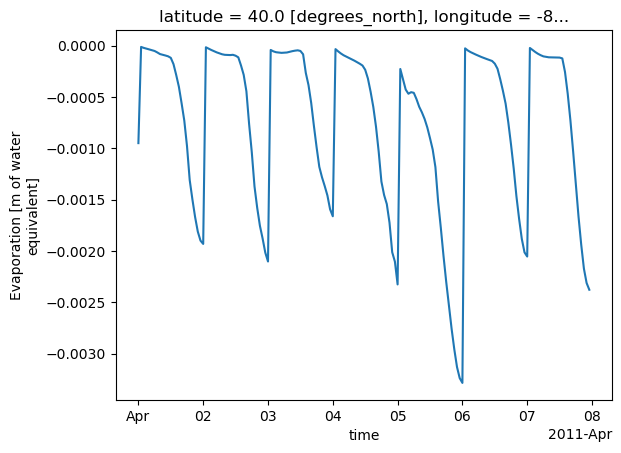

In [69]:
ds['e'].plot()

In [2]:
# ----
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'surface_solar_radiation_downwards',
        'year': [str(y) for y in range(1981, 2011)],
        'month': [f'{m:02d}' for m in range(1, 13)],
        'time': '00:00',
        'format': 'netcdf',
        'area': [38, -113, 35, -107],  # North, West, South, East
    },
    'era5_shortwave_down_1981_2010.nc'
)


2025-07-23 02:22:45,028 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-07-23 02:22:45,648 INFO Request ID is 314087d5-c233-4d77-b964-fc86edd8862a
2025-07-23 02:22:45,860 INFO status has been updated to accepted
2025-07-23 02:23:00,232 INFO status has been updated to running
2025-07-23 02:24:03,306 INFO status has been updated to successful


'era5_shortwave_down_1981_2010.nc'

In [12]:
import cdsapi
import xarray as xr
import numpy as np
import os

# Define bounding box
minlat, maxlat = 35, 38
minlon, maxlon = -113, -107

# Download using CDS API
target_file = 'era5_downwelling_thermal_1981_2010.nc' # "era5_2m_temp_1981_2010.nc"
target_var = "surface_thermal_radiation_downwards" # "surface_solar_radiation_downwards" # "2m_temperature"
# if not os.path.exists(target_file):
c = cdsapi.Client()
c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': target_var,
        'year': [str(y) for y in range(1981, 2011)],
        'month': [f'{m:02d}' for m in range(1, 13)],
        'time': '00:00',
        'format': 'netcdf',
        'area': [maxlat, minlon, minlat, maxlon],  # [N, W, S, E]
    },
    target_file)

# Open and process
ds = xr.open_dataset(target_file)
# t2m = ds['t2m'] - 273.15  # Convert to Celsius

# # Mean over time, lat, lon
# climatology = t2m.mean(dim=["valid_time", "latitude", "longitude"])
# print(f"Mean annual 2m temperature (1981–2010): {climatology.values:.2f} °C")


2025-07-23 02:33:19,760 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-07-23 02:33:20,530 INFO Request ID is 17f66fc7-81b1-45e6-802e-9342e54bd9ea
2025-07-23 02:33:20,753 INFO status has been updated to accepted
2025-07-23 02:33:26,377 INFO status has been updated to running
2025-07-23 02:34:38,562 INFO status has been updated to successful


In [13]:
s_per_day = 86400 #* 30
ds.sel(latitude = slice(36,35), longitude = slice(-110, -109)).mean(dim=["valid_time", "latitude", "longitude"]) / s_per_day


<xarray.Dataset> Size: 12B
Dimensions:  ()
Coordinates:
    number   int64 8B ...
Data variables:
    strd     float32 4B 271.7